# Benchmark Grouped Plots

This notebook is a notebook-style conversion of `benchmark/plotting.py` for interactive use.

It accepts **multiple benchmark CSV paths** and plots them as **separate groups** in one chart.

## Expected CSV columns
- `scale_factor`
- `query_id`
- `system` (e.g. `DuckDB`, `Bespoke`)
- `time_ms`
- `hostname` (optional)

## Usage
1. Edit `benchmark_files` in the last cell.
2. Optionally set `target_scale_factor` and `target_hostnames`.
3. Run all cells.

In [11]:
from __future__ import annotations

import csv
import statistics
from pathlib import Path
from typing import Dict

import matplotlib.pyplot as plt
import numpy as np


_COLOR_BESPOKE = "#2E86AB"
_EDGE_BESPOKE = "#1a4d6f"
_COLOR_DUCK = "#E8E8E8"
_EDGE_DUCK = "#333333"
_COLOR_SPEEDUP = "#FF6B6B"


def _apply_journal_rcparams() -> None:
    plt.rcParams["figure.dpi"] = 300
    plt.rcParams["font.size"] = 11
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["axes.linewidth"] = 1.2
    plt.rcParams["xtick.major.width"] = 1.2
    plt.rcParams["ytick.major.width"] = 1.2
    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.2


def _style_ax(ax) -> None:
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5)


def _qlabel(qid: str) -> str:
    return f"Q{qid.lstrip('0') or '0'}"


def _load_rows(csv_path: Path) -> list[dict[str, str]]:
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        return list(csv.DictReader(f))


def _stats(values: list[float]) -> tuple[float, float]:
    if not values:
        return 0.0, 0.0
    if len(values) == 1:
        return values[0], 0.0
    return statistics.mean(values), statistics.pstdev(values)

In [12]:
def load_benchmark_metrics(
    csv_path: str | Path,
    scale_factor: int | float | None = None,
    hostnames: list[str] | None = None,
    exclude_query_ids: tuple[str, ...] = ("8a",),
) -> dict:
    path = Path(csv_path)
    rows = _load_rows(path)

    if hostnames:
        host_set = set(hostnames)
        rows = [r for r in rows if r.get("hostname") in host_set]

    if scale_factor is not None:
        rows = [r for r in rows if str(r.get("scale_factor")) == str(scale_factor)]

    rows = [r for r in rows if r.get("query_id") not in set(exclude_query_ids)]

    grouped: Dict[tuple[str, str], list[float]] = {}
    for row in rows:
        qid = row.get("query_id")
        system = row.get("system")
        time_ms = row.get("time_ms")
        if not qid or not system or not time_ms:
            continue
        grouped.setdefault((qid, system), []).append(float(time_ms))

    query_ids = sorted({qid for qid, _ in grouped.keys()}, key=lambda x: x)
    per_query: dict[str, dict[str, float]] = {}
    for qid in query_ids:
        b_mean, _ = _stats(grouped.get((qid, "Bespoke"), []))
        d_mean, _ = _stats(grouped.get((qid, "DuckDB"), []))
        per_query[qid] = {"Bespoke": b_mean, "DuckDB": d_mean}

    total_bespoke = sum(v["Bespoke"] for v in per_query.values())
    total_duckdb = sum(v["DuckDB"] for v in per_query.values())

    return {
        "label": path.stem,
        "path": str(path),
        "query_ids": query_ids,
        "per_query": per_query,
        "total_bespoke_ms": total_bespoke,
        "total_duckdb_ms": total_duckdb,
    }


def plot_grouped_benchmarks(
    benchmark_paths: list[str | Path],
    scale_factor: int | float | None = None,
    hostnames: list[str] | None = None,
    figsize_height: float = 6.5,
):
    if not benchmark_paths:
        raise ValueError("benchmark_paths must contain at least one CSV path.")

    _apply_journal_rcparams()

    benchmarks = [
        load_benchmark_metrics(p, scale_factor=scale_factor, hostnames=hostnames)
        for p in benchmark_paths
    ]

    all_queries = sorted(
        {qid for b in benchmarks for qid in b["query_ids"]},
        key=lambda x: x,
    )
    if not all_queries:
        raise ValueError("No matching rows found in the provided files.")

    group_gap = 1.2
    bar_width = 0.36

    x_positions = []
    duck_vals = []
    bespoke_vals = []
    qlabels = []
    group_centers = []
    group_starts = []
    group_ends = []

    x_cursor = 0.0
    for bench in benchmarks:
        start = x_cursor
        for qid in all_queries:
            metrics = bench["per_query"].get(qid, {"DuckDB": 0.0, "Bespoke": 0.0})
            x_positions.append(x_cursor)
            duck_vals.append(metrics["DuckDB"])
            bespoke_vals.append(metrics["Bespoke"])
            qlabels.append(_qlabel(str(qid)))
            x_cursor += 1.0
        end = x_cursor - 1.0
        group_starts.append(start)
        group_ends.append(end)
        group_centers.append((start + end) / 2.0)
        x_cursor += group_gap

    x = np.array(x_positions)
    duck_arr = np.array(duck_vals)
    bespoke_arr = np.array(bespoke_vals)

    max_runtime = max(float(duck_arr.max()), float(bespoke_arr.max()))
    div = 1000.0 if max_runtime >= 1000.0 else 1.0
    unit = "s" if div == 1000.0 else "ms"

    duck_plot = duck_arr / div
    bespoke_plot = bespoke_arr / div

    fig, ax = plt.subplots(figsize=(max(12, len(x_positions) * 0.35), figsize_height))

    ax.bar(
        x - bar_width / 2,
        duck_plot,
        bar_width,
        label="DuckDB",
        color=_COLOR_DUCK,
        edgecolor=_EDGE_DUCK,
        linewidth=2.0,
        alpha=1.0,
    )
    ax.bar(
        x + bar_width / 2,
        bespoke_plot,
        bar_width,
        label="Bespoke",
        color=_COLOR_BESPOKE,
        edgecolor=_EDGE_BESPOKE,
        linewidth=2.0,
        alpha=0.95,
    )

    pair_tops = np.maximum(duck_plot, bespoke_plot)
    top_max = float(pair_tops.max()) if len(pair_tops) else 0.0
    for i, (d, b) in enumerate(zip(duck_plot, bespoke_plot)):
        if b > 0 and d > 0:
            sp = d / b
            ax.text(
                x[i],
                pair_tops[i] + top_max * 0.015,
                f"{sp:.2f}x",
                ha="center",
                va="bottom",
                fontsize=7,
                fontweight="bold",
                color=_COLOR_SPEEDUP,
            )

    for idx, center in enumerate(group_centers):
        label = benchmarks[idx]["label"]
        ax.text(
            center,
            -0.2,
            label,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=10,
            fontweight="bold",
        )

    for i in range(len(group_ends) - 1):
        sep_x = (group_ends[i] + group_starts[i + 1]) / 2.0
        ax.axvline(sep_x, color="#999999", linestyle="--", linewidth=1.0, alpha=0.6)

    ax.set_ylabel(f"Runtime ({unit})", fontsize=12, fontweight="bold")
    ax.set_title("Grouped Benchmark Comparison", fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(qlabels, rotation=90, fontsize=8)
    ax.set_ylim(0, max(1e-9, top_max * 1.16))
    ax.legend(frameon=False, fontsize=10)
    _style_ax(ax)

    fig.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=0.0)

    return fig, ax, benchmarks

In [13]:
def _to_sf_number(value: str):
    try:
        if "." in value:
            return float(value)
        return int(value)
    except ValueError:
        return value


def collect_scale_factor_totals(
    csv_path: str | Path,
    hostnames: list[str] | None = None,
    exclude_query_ids: tuple[str, ...] = ("8a",),
) -> dict:
    path = Path(csv_path)
    rows = _load_rows(path)

    if hostnames:
        host_set = set(hostnames)
        rows = [r for r in rows if r.get("hostname") in host_set]

    rows = [r for r in rows if r.get("query_id") not in set(exclude_query_ids)]

    grouped: Dict[tuple[str, str, str], list[float]] = {}
    for row in rows:
        sf = str(row.get("scale_factor", "")).strip()
        qid = row.get("query_id")
        system = row.get("system")
        time_ms = row.get("time_ms")
        if not sf or not qid or not system or not time_ms:
            continue
        grouped.setdefault((sf, qid, system), []).append(float(time_ms))

    scale_factors = sorted({sf for sf, _, _ in grouped.keys()}, key=_to_sf_number)

    totals_by_sf: dict[str, dict[str, float]] = {}
    for sf in scale_factors:
        qids = sorted({qid for sfi, qid, _ in grouped.keys() if sfi == sf})
        total_bespoke = 0.0
        total_duckdb = 0.0
        for qid in qids:
            b_mean, _ = _stats(grouped.get((sf, qid, "Bespoke"), []))
            d_mean, _ = _stats(grouped.get((sf, qid, "DuckDB"), []))
            total_bespoke += b_mean
            total_duckdb += d_mean
        totals_by_sf[sf] = {
            "Bespoke": total_bespoke,
            "DuckDB": total_duckdb,
        }

    return {
        "label": path.stem,
        "path": str(path),
        "scale_factors": scale_factors,
        "totals_by_sf": totals_by_sf,
    }


def plot_grouped_scale_factors(
    benchmark_paths: list[str | Path],
    hostnames: list[str] | None = None,
    group_label_dict: dict[str, str] | None = None,
    overwrite: dict[str, dict[str, float]] | None = None,
    figsize_height: float = 3,
):
    if not benchmark_paths:
        raise ValueError("benchmark_paths must contain at least one CSV path.")

    _apply_journal_rcparams()

    summaries = [
        collect_scale_factor_totals(p, hostnames=hostnames) for p in benchmark_paths
    ]
    summaries = [s for s in summaries if s["scale_factors"]]

    if not summaries:
        raise ValueError("No scale factor data found in the provided files.")

    n_groups = len(summaries)
    fig_width = max(8, 3 * n_groups)
    fig, axes = plt.subplots(
        1,
        n_groups,
        figsize=(fig_width, figsize_height),
        squeeze=False,
        sharey=False,
    )
    axes = axes[0]

    bar_width = 0.36
    legend_handles = None

    for idx, (ax, summary) in enumerate(zip(axes, summaries)):
        own_sfs = summary["scale_factors"]
        totals_by_sf = summary["totals_by_sf"]

        x = np.arange(len(own_sfs), dtype=float)
        duck_arr = np.array([totals_by_sf[sf]["DuckDB"] for sf in own_sfs], dtype=float)
        bespoke_arr = np.array(
            [totals_by_sf[sf]["Bespoke"] for sf in own_sfs], dtype=float
        )

        max_runtime = max(float(duck_arr.max()), float(bespoke_arr.max()))
        div = 1000.0 if max_runtime >= 1000.0 else 1.0
        unit = "s" if div == 1000.0 else "ms"

        duck_plot = duck_arr / div
        bespoke_plot = bespoke_arr / div

        bars_duck = ax.bar(
            x - bar_width / 2,
            duck_plot,
            bar_width,
            label="DuckDB",
            color=_COLOR_DUCK,
            edgecolor=_EDGE_DUCK,
            linewidth=2.0,
            alpha=1.0,
        )
        bars_bespoke = ax.bar(
            x + bar_width / 2,
            bespoke_plot,
            bar_width,
            label="Bespoke",
            color=_COLOR_BESPOKE,
            edgecolor=_EDGE_BESPOKE,
            linewidth=2.0,
            alpha=0.95,
        )

        if legend_handles is None:
            legend_handles = [bars_duck[0], bars_bespoke[0]]

        pair_tops = np.maximum(duck_plot, bespoke_plot)
        top_max = float(pair_tops.max()) if len(pair_tops) else 0.0
        for i, (d, b) in enumerate(zip(duck_plot, bespoke_plot)):
            if b > 0 and d > 0:
                sf_key = str(own_sfs[i])
                sp_override = None
                if overwrite:
                    sp_override = overwrite.get(summary["label"], {}).get(sf_key)
                sp = float(sp_override) if sp_override is not None else (d / b)
                ax.text(
                    x[i],
                    pair_tops[i] + top_max * 0.03,
                    f"{sp:.2f}x",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    fontweight="bold",
                    color=_COLOR_SPEEDUP,
                )

        display_label = summary["label"]
        if group_label_dict:
            display_label = group_label_dict.get(summary["label"], display_label)

        if idx == 0:
            ax.set_ylabel(f"Total Runtime ({unit})", fontsize=12, fontweight="bold")
        ax.set_xlabel("Scale factor", fontsize=11, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels([str(sf) for sf in own_sfs], rotation=0, fontsize=10)
        ax.set_ylim(0, max(1e-9, top_max * 1.18))
        _style_ax(ax)
        ax.text(
            0.5,
            -0.22,
            display_label,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=13,
            fontweight="bold",
        )

        if idx > 0:
            ax.tick_params(axis="y", labelleft=True)

    if legend_handles is not None:
        fig.legend(
            legend_handles,
            ["DuckDB", "Bespoke"],
            loc="lower center",
            ncol=2,
            frameon=False,
            bbox_to_anchor=(0.5, -0.26),
            fontsize=11,
        )

    fig.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=0.0)

    return fig, axes, summaries

In [16]:
def plot_speedup_by_scale_factor(
    benchmark_paths: list[str | Path],
    hostnames: list[str] | None = None,
    group_label_dict: dict[str, str] | None = None,
    overwrite: dict[str, dict[str, float]] | None = None,
):
    if not benchmark_paths:
        raise ValueError("benchmark_paths must contain at least one CSV path.")

    _apply_journal_rcparams()

    summaries = [
        collect_scale_factor_totals(p, hostnames=hostnames) for p in benchmark_paths
    ]
    summaries = [s for s in summaries if s["scale_factors"]]

    if not summaries:
        raise ValueError("No scale factor data found in the provided files.")

    n_groups = len(summaries)
    fig_width = max(3.5, 2.5 * n_groups)
    fig, axes = plt.subplots(
        1,
        n_groups,
        figsize=(fig_width, 2),
        squeeze=False,
        sharey=True,
    )
    axes = axes[0]

    for idx, (ax, summary) in enumerate(zip(axes, summaries)):
        own_sfs = summary["scale_factors"]
        totals_by_sf = summary["totals_by_sf"]

        x_line = np.arange(len(own_sfs), dtype=float)
        y_values: list[float] = []
        for sf in own_sfs:
            sf_key = str(sf)
            sp_override = None
            if overwrite:
                sp_override = overwrite.get(summary["label"], {}).get(sf_key)
            if sp_override is not None:
                y_values.append(float(sp_override))
            elif float(totals_by_sf[sf]["Bespoke"]) > 0:
                y_values.append(
                    float(totals_by_sf[sf]["DuckDB"])
                    / float(totals_by_sf[sf]["Bespoke"])
                )
            else:
                y_values.append(np.nan)
        y_line = np.array(y_values, dtype=float)

        display_label = summary["label"]
        if group_label_dict:
            display_label = group_label_dict.get(summary["label"], display_label)

        # display_label_lower = str(display_label).lower()
        # if "ceb" in display_label_lower:
        #     line_color = "#62B4E4"
        #     marker_style = "o"
        # elif "tpc" in display_label_lower or "tpch" in display_label_lower:
        #   line_color = "#2E86AB"
        #   marker_style = "s"
        # else:
        #     line_color = None
        #     marker_style = "o"
        line_color = "#2E86AB"
        marker_style = "s"

        ax.plot(
            x_line,
            y_line,
            marker=marker_style,
            linewidth=2.2,
            markersize=5,
            color=line_color,
        )

        top_speedup = 70  # float(valid_vals.max()) if len(valid_vals) else 1.0

        ax.set_xlabel("Scale Factor", fontsize=11, fontweight="bold")
        if idx == 0:
            ax.set_ylabel("Speedup\n(DuckDB/Bespoke)", fontsize=12, fontweight="bold")
        ax.set_xticks(x_line)
        ax.set_xticklabels([str(sf) for sf in own_sfs], fontsize=10)
        ax.set_xlim(-0.5, len(own_sfs) - 0.5)
        ax.set_ylim(0, max(1.0, top_speedup * 1.15))
        _style_ax(ax)

        label_offset = max(0.03, top_speedup * 0.03)
        for xv, yv in zip(x_line, y_line):
            if np.isnan(yv):
                continue
            if yv > 10:
                yv_str = f"{yv:.1f}"
            else:
                yv_str = f"{yv:.2f}"
            ax.text(
                xv,
                yv + label_offset,
                yv_str,
                ha="center",
                va="bottom",
                fontsize=9,
                color="black",
            )

        ax.set_title(display_label, fontsize=12, fontweight="bold", pad=6)

    fig.subplots_adjust(left=0.0, right=1.0, top=0.92, bottom=0.0, wspace=0.08)

    return fig, axes, summaries

=== Per-file totals from Plot 1 ===
tpch_optim2: total DuckDB=85834.62ms, Bespoke=8208.17ms, speedup=10.46x
ceb_optim2: total DuckDB=71842.22ms, Bespoke=3742.65ms, speedup=19.20x

=== Per-file, per-scale-factor totals from Plot 2 ===
tpch_optim2:
  SF 1: DuckDB=2207.43ms, Bespoke=238.00ms, speedup=9.27x
  SF 2: DuckDB=4424.17ms, Bespoke=478.00ms, speedup=9.26x
  SF 10: DuckDB=26055.93ms, Bespoke=2433.00ms, speedup=11.78x
  SF 20: DuckDB=54179.79ms, Bespoke=4989.00ms, speedup=10.86x
  SF 50: DuckDB=141917.97ms, Bespoke=13255.00ms, speedup=10.71x
  SF 100: DuckDB=286222.44ms, Bespoke=27856.00ms, speedup=10.28x
ceb_optim2:
  SF 0.25: DuckDB=4729.13ms, Bespoke=1526.77ms, speedup=3.10x
  SF 0.5: DuckDB=5914.17ms, Bespoke=2103.31ms, speedup=2.81x
  SF 1: DuckDB=9408.15ms, Bespoke=2493.92ms, speedup=3.77x
  SF 2: DuckDB=35785.47ms, Bespoke=4065.15ms, speedup=9.74x
  SF 5: DuckDB=142996.83ms, Bespoke=8107.55ms, speedup=17.64x
  SF 10: DuckDB=1559581.13ms, Bespoke=22278.00ms, speedup=70.01x


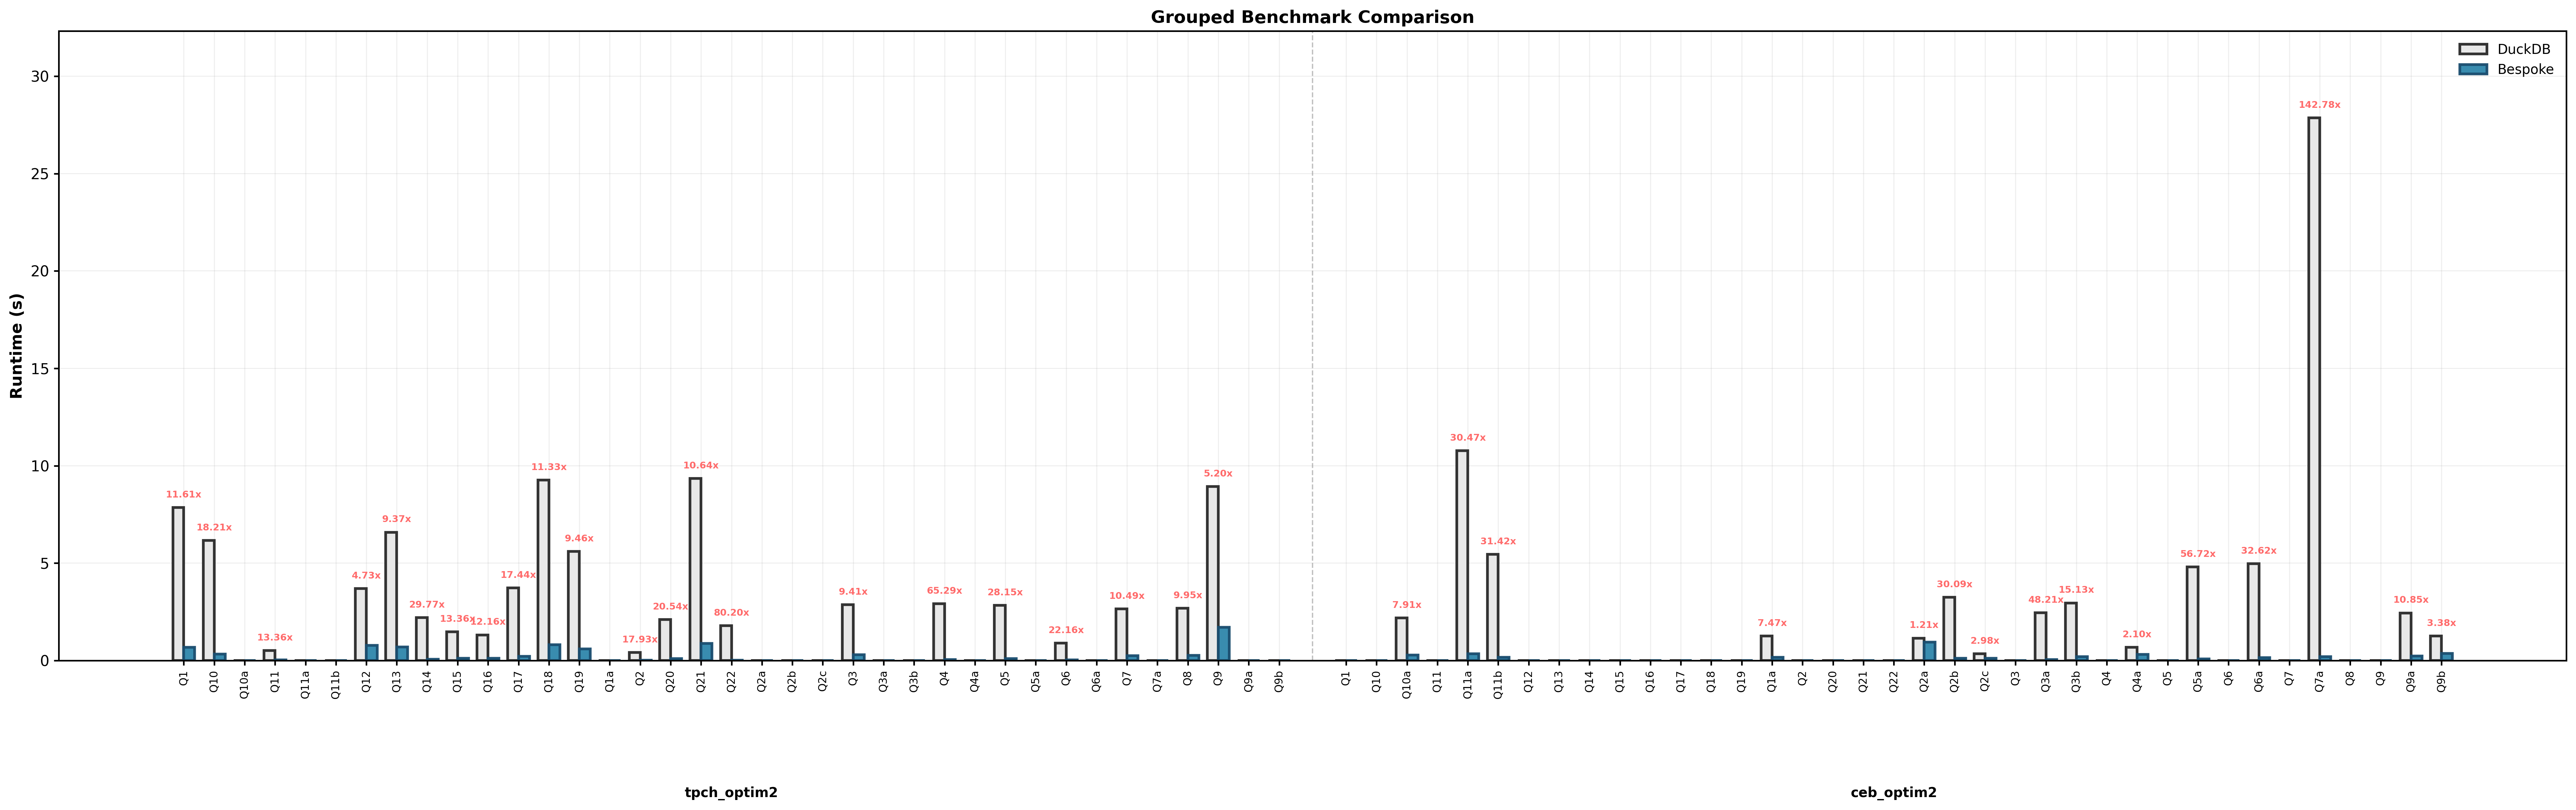

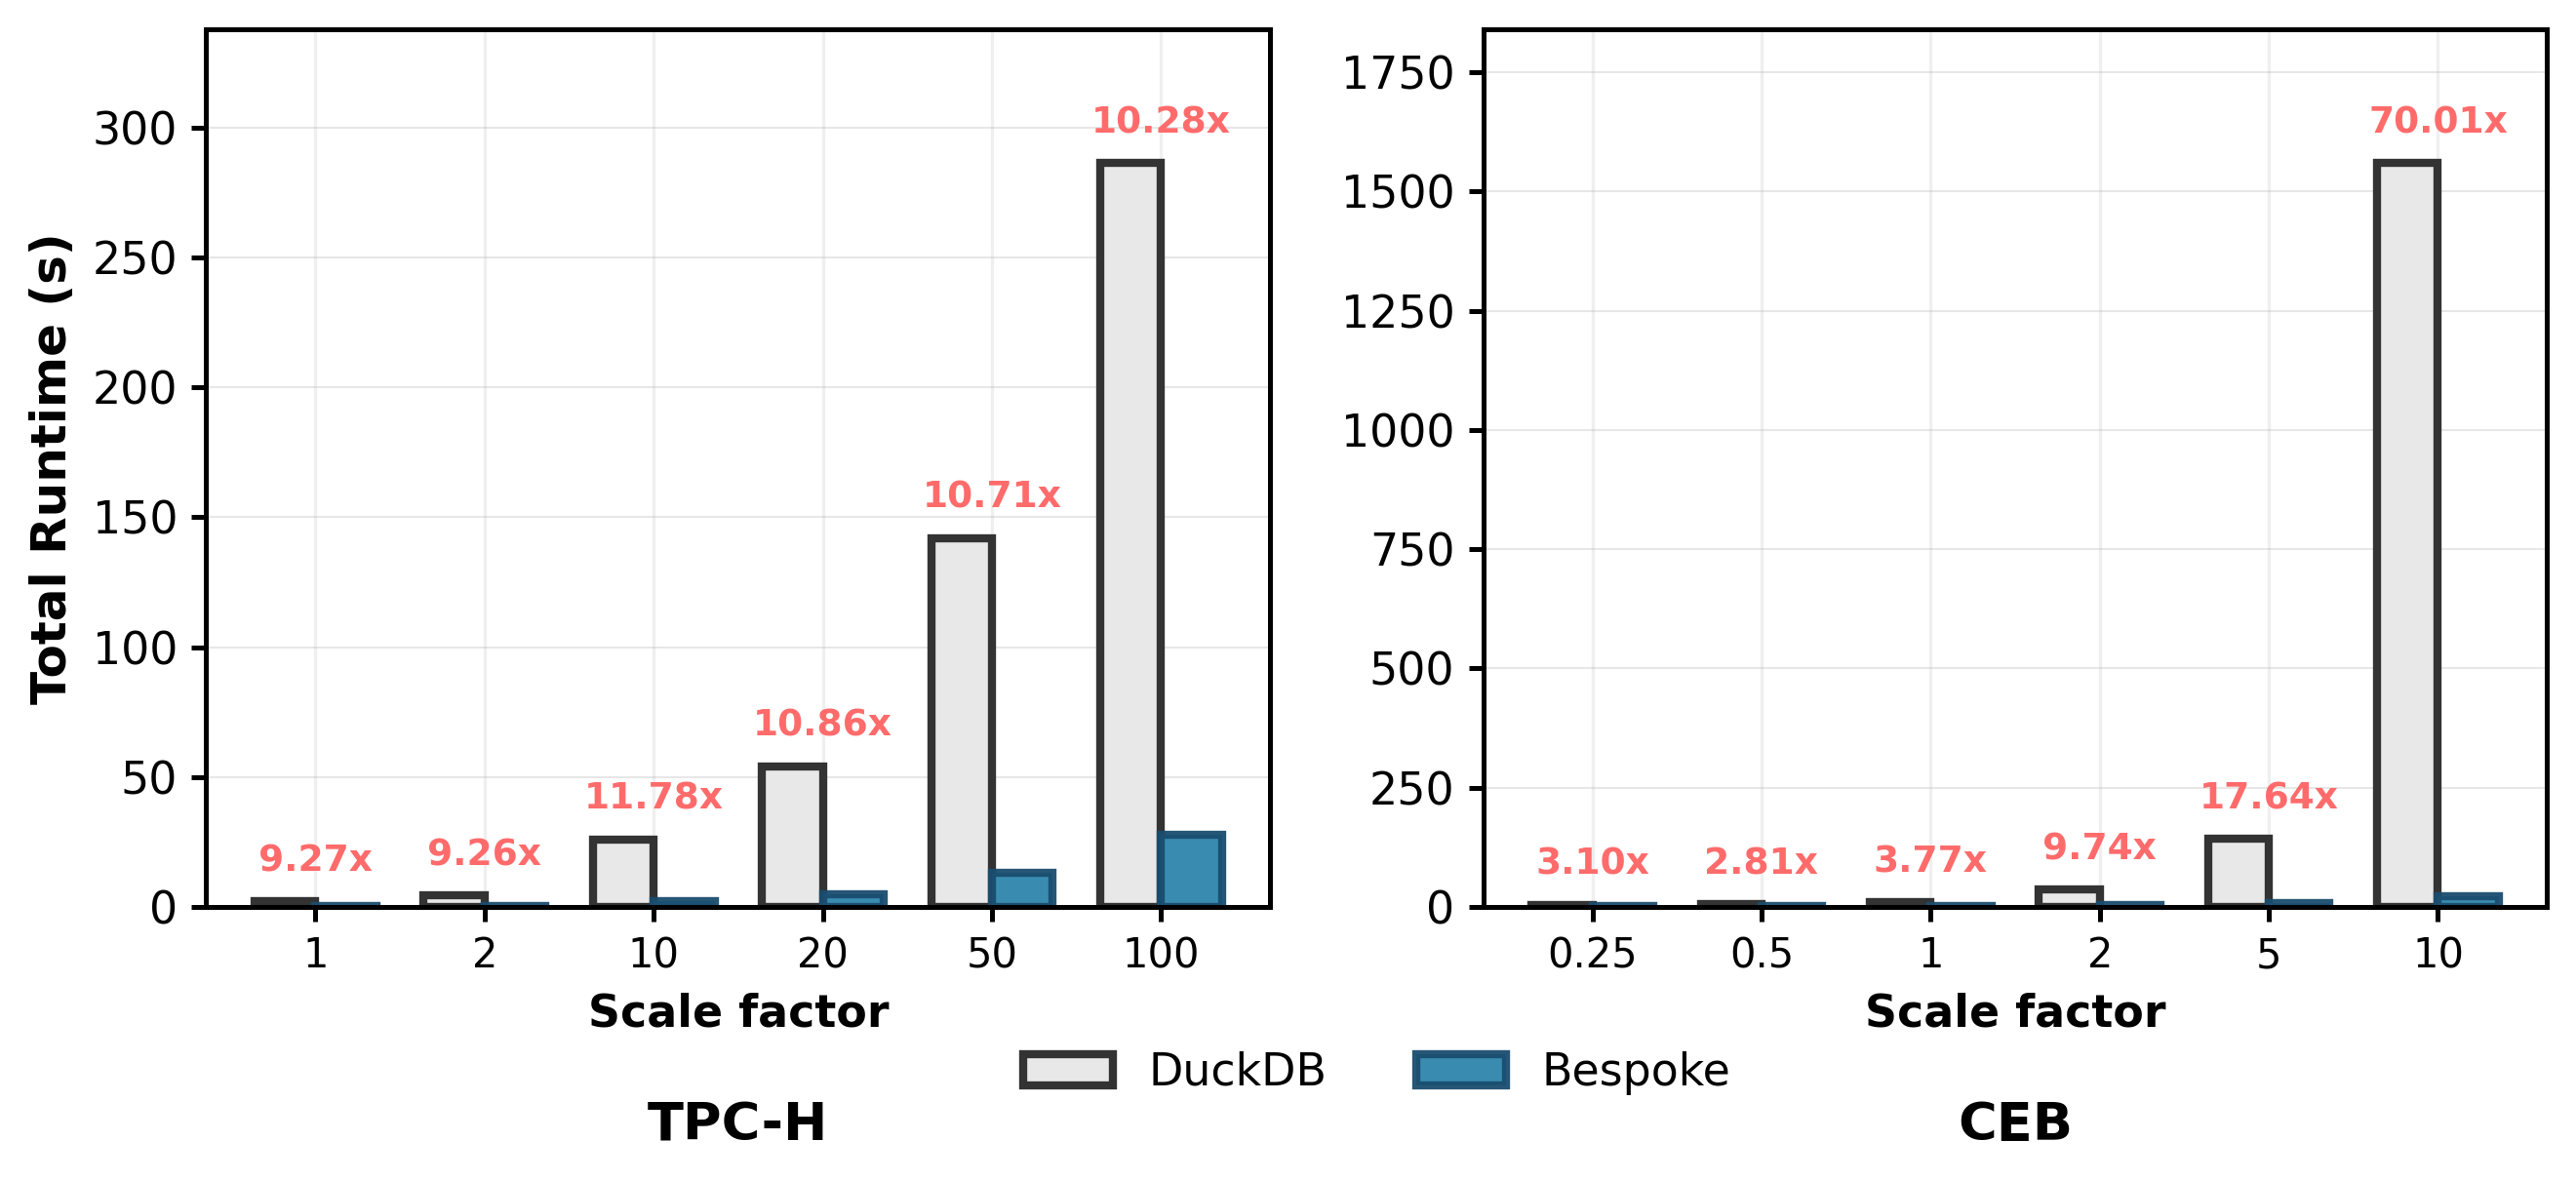

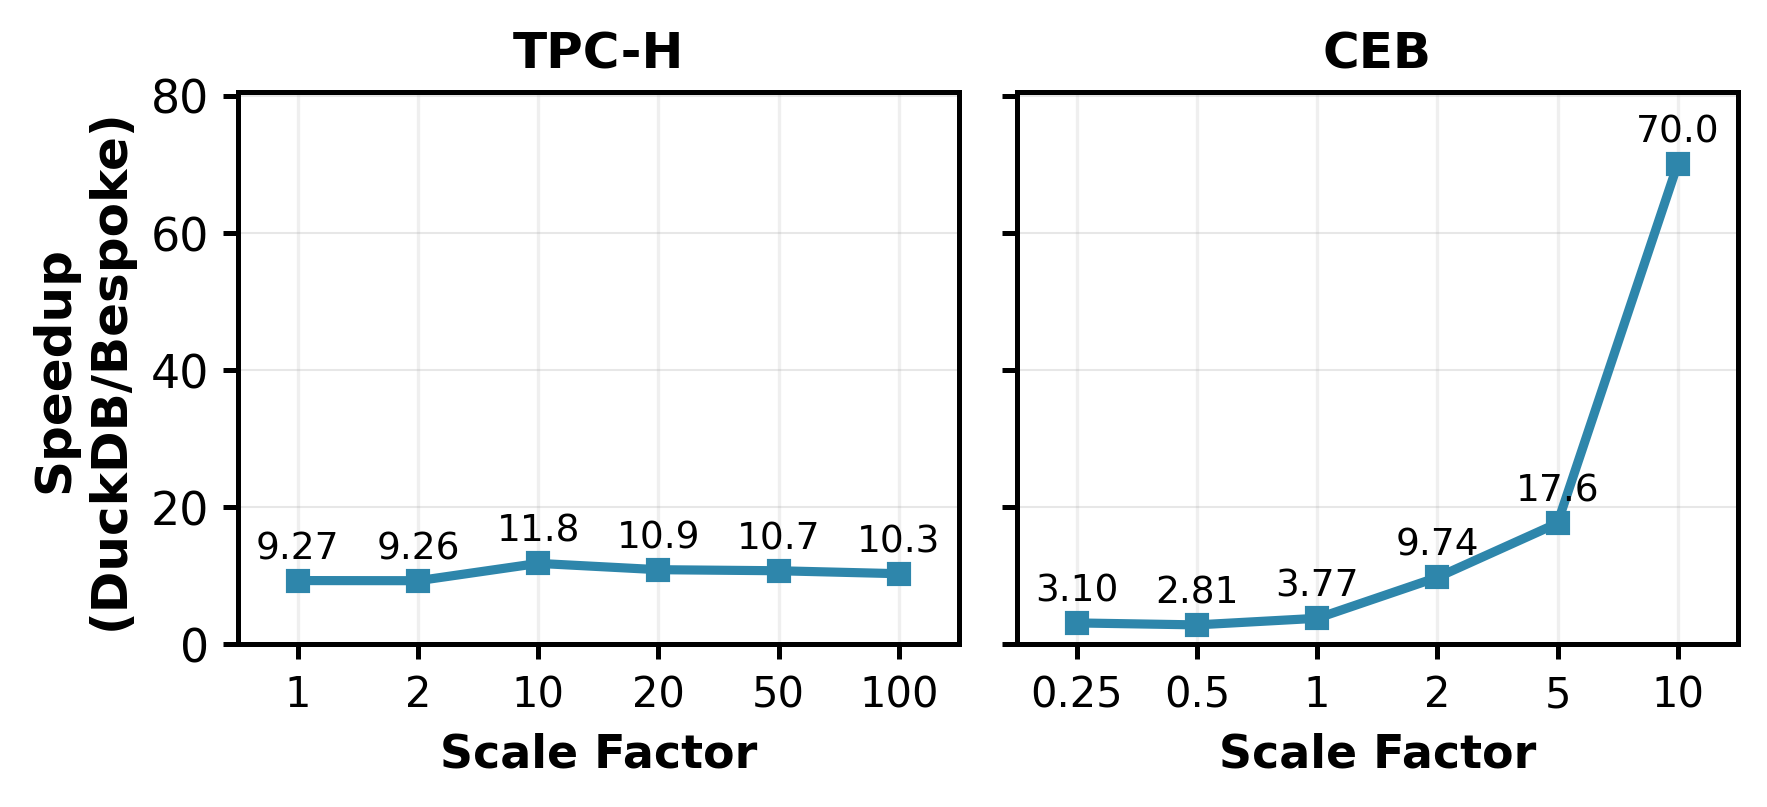

In [17]:
# --- Inputs: provide multiple benchmark CSV files here ---
benchmark_files = ["output/tpch_optim2.csv", "output/ceb_optim2.csv"]

# Optional filters (used for the per-query chart)
target_scale_factor = None  # e.g. 10
target_hostnames = None  # e.g. ["machine-1", "machine-2"]

# Optional pretty labels for benchmark groups (uses file stem as key)
group_label_dict = {
    "tpch_optim2": "TPC-H",
    "ceb_optim2": "CEB",
    "ceb_optim": "CEB",
}

# utilize numbers from the optimization run
# per-SF benchmarking happened separately, because of noise is slighly different then numbers from final step during code generation
# overwrite here to make numbers consistent through the paper

overwrite = {
    "tpch_optim2": {
        "10": 11.78,  # see notebooks in /plots/...
    },
    "ceb_optim2": {
        "2": 9.74,  # see notebooks in /plots/...
    },
}

if not benchmark_files:
    raise ValueError("Add at least one CSV path to benchmark_files before running.")

# Plot 1: per-query runtime comparison (grouped by benchmark file)
fig1, ax1, benchmark_summary = plot_grouped_benchmarks(
    benchmark_files,
    scale_factor=target_scale_factor,
    hostnames=target_hostnames,
)

# Plot 2: scale-factor total runtime comparison (grouped by benchmark file)
fig2, ax2, scale_factor_summary = plot_grouped_scale_factors(
    benchmark_files,
    hostnames=target_hostnames,
    group_label_dict=group_label_dict,
    overwrite=overwrite,
)

# Plot 3: speedup by scale factor (line chart, one line per benchmark group)
fig3, ax3, speedup_summary = plot_speedup_by_scale_factor(
    benchmark_files,
    hostnames=target_hostnames,
    group_label_dict=group_label_dict,
    overwrite=overwrite,
)

# save as pdf
fig2.savefig("output/scale_factor_comparison.pdf", bbox_inches="tight", pad_inches=0)
fig3.savefig("output/speedup_by_scale_factor.pdf", bbox_inches="tight", pad_inches=0.01)

print("=== Per-file totals from Plot 1 ===")
for item in benchmark_summary:
    d = item["total_duckdb_ms"]
    b = item["total_bespoke_ms"]
    speedup = (d / b) if b > 0 else float("nan")
    print(
        f"{item['label']}: total DuckDB={d:.2f}ms, Bespoke={b:.2f}ms, speedup={speedup:.2f}x"
    )

print("\n=== Per-file, per-scale-factor totals from Plot 2 ===")
for item in scale_factor_summary:
    print(f"{item['label']}:")
    for sf in item["scale_factors"]:
        metrics = item["totals_by_sf"][sf]
        d = metrics["DuckDB"]
        b = metrics["Bespoke"]
        speedup = (d / b) if b > 0 else float("nan")
        override_speedup = overwrite.get(item["label"], {}).get(str(sf))
        if override_speedup is not None:
            speedup = float(override_speedup)
        print(f"  SF {sf}: DuckDB={d:.2f}ms, Bespoke={b:.2f}ms, speedup={speedup:.2f}x")

plt.show()